# Simulating Habitable Worlds Observatory Reflection Spectra with POSEIDON

In this tutorial, we will go over creating a modern Earth spectra worthy of your favorite next-generation high-contrast imaging telescope.

We will cover the following four things in this tutorial:

1. Creating "simple" Earth refected light spectra
2. Using external atmospheric and surface models for a more complex Earth
3. Simulating HWO-like noise to the spectra

The simple Earth models will contain uniform vertical mixing ratios and isothermal PT profile. They will also demonstrate how to initialize a constant-with-wavelength albedo surface, and a surface composed of laboratory-based measurements (only four basic components). One model will be clear, and one will be cloudy (with patchy clouds). 

For our complex models, we will use custom atmospheric and surface model input files. 

We will also show how the pressure grid must be adjusted to be more fine in order to account for Earth-like clouds in the spectra, and how to define a model that only computes reflect light with no thermal component. 

By the end, you will be able to create modern Earth models in POSEIDON like the one below from [Zelakiewicz et al. 2026](https://ui.adsabs.harvard.edu/abs/2026arXiv260325694Z/abstract), and Figure A1 from Mullens et al. 2026 (in prep). 

<img src="../../_static/paper_images/Zelakiewicz_2026.png" />

<div class="alert alert-info">

  **Note:**

  If you end up using the reflection modules in POSEIDON (for HWO applications), please consider citing [Zelakiewicz et al. 2026](https://ui.adsabs.harvard.edu/abs/2026arXiv260325694Z/abstract) and Mullens et al. 2026 (in prep).

</div>

### Defining bulk planetary parameters

Below, we will first start by defining the `star` and `planet` objects that will remain constant throughout both models.

Here we use the familiar parameters of our very own Earth 🌍 and Sun ☀️.

In [1]:
from POSEIDON.constants import R_Sun, R_E, M_E
from POSEIDON.core import create_planet, create_star, wl_grid_constant_R

from scipy.constants import au
from scipy.constants import parsec as pc

#***** Model wavelength grid *****#

wl_min = 0.25    # Minimum wavelength (um)
wl_max = 2.0     # Maximum wavelength (um)
R = 10000        # Spectral resolution of grid

# Create the wavelength grid
wl = wl_grid_constant_R(wl_min, wl_max, R)

#***** Define planet properties *****#

planet_name = 'Earth'  # Planet name used for plots, output files etc.

R_p = 1.0 * R_E    # Planetary radius (m)
M_p = 1.0 * M_E    # Planetary mass (kg)
d = 10.0 * pc    # Distance to system (m)
a_p = 1.0 * au   # Planetary semi-major axis (m), needed for reflection!

# Create the planet object
planet = create_planet(planet_name, R_p, mass = M_p, a_p = a_p, d = d)


#***** Define stellar properties *****#

R_s = 1. * R_Sun   # Stellar radius (m)
T_s = 5772.         # Stellar effective temperature (K)
Met_s = 0.       # Stellar metallicity [log10(Fe/H_star / Fe/H_solar)] 
log_g_s = 4.4     # Stellar log surface gravity (log10(cm/s^2) by convention)

# Create the stellar object
star = create_star(R_s, T_s, log_g_s, Met_s, wl = wl, stellar_grid = 'phoenix')

### 1. Creating Simple Modern Earth Spectra

We will create two versions of a  simple modern Earth model, which is useful for benchmarking. 

The first is the constant albedo, clear model from Figure A1 of Mullens et al. 2026. The second is identical to the "50\% Cloud Cover" model from [Zelakiewicz et al. 2026](https://ui.adsabs.harvard.edu/abs/2026arXiv260325694Z/abstract).

### Surface:

As defined in the **Reflecting and Emitting Surfaces** tutorial notebook, POSEIDON has three surface options in `define_model()`.

Here we will focus on the constant surface albedo and one that uses lab data.

For our constant surface albedo we will assume a constant-with-wavelength surface albedo of 0.3.

For our `lab_data` surface we will assume the Earth is made of four surfaces: ocean, forest, snow, and sand. Each of these surfaces will be assigned the coverage $f_{\rm ocean}=0.70$, $f_{\rm forest}=0.15$, $f_{\rm snow}=0.05$, and $f_{\rm sand}=0.10$. The spectra used in [Zelakiewicz et al. 2026](https://ui.adsabs.harvard.edu/abs/2026arXiv260325694Z/abstract) are provided natively in POSEIDON; ocean, aspen leaf, and quartz sand from [USGS Spectral Library Version 7 (Kokaly et al. 2017)](https://www.usgs.gov/labs/spectroscopy-lab/usgs-spectral-library) and antarctic spectra. from [Grenfell et al. 1994](https://ui.adsabs.harvard.edu/abs/1994JGR....9918669G/abstract).

### Atmosphere:
The atmosphere will be isothermal with constant vertical mixing ratios of ${\rm H_2O}$, ${\rm O_2}$, ${\rm O_3}$, ${\rm CH_4}$ with an ${\rm N_2}$ background gas. For our model utilizing a lab data surface, we will also assume a patchy 50\% coverage of optically thick water clouds.

### Reflection Only
In the wavelengths we are interested in for HWO (0.4-1.8 microns), and planetary temperatures (Earth-like), thermal emission does not contribute much to the spectrum. In order to speed up computations, wwe can turn thermal components off and only compute reflected light spectra.

In [2]:
from POSEIDON.core import define_model

#***** Define models *****#

# Model 1 - Simple Earth with constant albedo surface and no clouds
model_name_simple_const_albedo = 'Simple-Earth-ConstAlbedo-Surface'

# Atmosphere species
bulk_species = ['N2']
param_species = ['H2O', 'O3', 'O2', 'CH4']

model_simple_const_albedo = define_model(model_name_simple_const_albedo, 
                                     bulk_species, param_species, 
                                     PT_profile = 'isotherm', X_profile = 'isochem',
                                     radius_unit = 'R_E', mass_unit = 'M_E',
                                     reflection = True, # <----- Set reflection to True
                                     thermal = False, thermal_scattering = False, # <----- Turn off thermal emission components
                                     surface = True,  # <----- Set surface = True
                                     surface_model = 'constant',  # <----- Set surface_model to 'lab_data'
                                    )

# Model 2 - Simple Earth with lab data surface and patchy water clouds 
model_name_simple_lab_data = 'Simple-Earth-LabData-Surface'

# Atmosphere species
bulk_species = ['N2']
param_species = ['H2O', 'O3', 'O2', 'CH4'] # Here, H2O is a gas
aerosol_species = ['H2O'] #Specifically, water ice clouds (use H2O_l for liquid water instead )

# List surface compoenents here 
# Names match the .txt files in 'surface_reflectivities' folder in 'inputs'
# Note that Goodis Gordon 2025 and Zelakiewicz 2026 use the same USGS ocean and sand datasets
surface_components = ['USGS_ocean_seawater_GG25',
                      'USGS_aspen_Z26',
                      'Grenfell1994_antarctic_Z26',
                      'USGS_quartz_sand_GG25']

model_simple_lab_data = define_model(model_name_simple_lab_data, 
                                     bulk_species, param_species, 
                                     PT_profile = 'isotherm', X_profile = 'isochem',
                                     radius_unit = 'R_E', mass_unit = 'M_E',
                                     reflection = True, # <----- Set reflection to True
                                     thermal = False, thermal_scattering = False, # <----- Turn off thermal emission components
                                     surface = True,  # <----- Set surface = True
                                     surface_model = 'lab_data',  # <----- Set surface_model to 'lab_data'
                                     surface_components = surface_components, # <----- Input surface_components
                                     surface_percentage_apply_to = 'albedos', # Apply percentages to albedos instead of models, speeding up computations
                                     cloud_model = 'Mie', cloud_type = 'slab', # Use the slab cloud model
                                     aerosol_species = aerosol_species, cloud_dim = 2,  # Define patchy clouds 
                                    )

Lets take a look at the parameters for each model:

In [3]:
print(model_simple_const_albedo['param_names'])
print()
print(model_simple_lab_data['param_names'])

['R_p_ref' 'T' 'log_H2O' 'log_O3' 'log_O2' 'log_CH4' 'log_P_surf'
 'albedo_surf']

['R_p_ref' 'T' 'log_H2O' 'log_O3' 'log_O2' 'log_CH4' 'f_cloud'
 'log_P_top_slab_H2O' 'Delta_log_P_H2O' 'log_r_m_H2O' 'log_X_H2O'
 'log_P_surf' 'USGS_ocean_seawater_GG25_percentage'
 'USGS_aspen_Z26_percentage' 'Grenfell1994_antarctic_Z26_percentage'
 'USGS_quartz_sand_GG25_percentage']


### Pressure Grid for Earth-like Planets

In POSEIDON, we usually define pressure grids in logspace like so: 

```python 
# Specify the pressure grid of the atmosphere
P_min = 1.0e-6    # 0.1 ubar
P_max = 100       # 100 bar
N_layers = 100    # 100 layers

# We'll space the layers uniformly in log-pressure
P = np.logspace(np.log10(P_max), np.log10(P_min), N_layers)

````

However, the pressure grid defined above is actually *too* sparse for modern Earth where clouds exist close to the surface and are relatively thin (in pressure space). If we use the "standard" pressure grid above, we will either significantly over- or underestimate their spectral contribution. 

Thus, for Earth models, we will want to define a custom pressure grid that has finer pressure spacing towards the surface to capture this, while making it coarser in the upper atmosphere for computational efficiency.

To do this, we will place 150 layers between $10^1$ and $10^{-2}$ bar and 50 layers from $10^{-2}$ and $10^{-6}$ bar. Placing the highest pressure below the 1 bar surface is fine because it will get cut off through the assignment of the `log_P_surf` variable.

In [4]:
import numpy as np
from POSEIDON.core import make_atmosphere

# Specify the pressure grid of the atmosphere
P_min = 1.0e-6 # 1e-6 is the top of the atmosphere
P_mid = 1.0e-2 # 1e-2 is our midpoint
P_max = 1.0e1  # 1e1 is the highest pressure we consider

P_top = np.logspace(np.log10(P_min), np.log10(P_mid), 50) # 150 layers between 10 and 1e-2 bars
P_bot = np.logspace(np.log10(P_mid), np.log10(P_max), 150) # 50 layers between 1e-2 and 1e-6 bars
P = np.concatenate((P_top, P_bot))

P = np.unique(P) # Making sure there are no duplicate pressures
P = P[::-1]      # Flip the array to match the ordering of a normal POSEIDON pressure grid 

# Make the atmosphere model
P_ref = 1.     # We'll set the reference pressure at the surface
R_p_ref = R_p  # Radius at reference pressure


#### Make Atmosphere 

Here we will make our atmosphere objects. 

In [5]:
# PT Properties 

T = 300 # K 

PT_params = np.array([T])

# Atmospheric Gases

log_H2O = -3    # -4 to perfectly recreate Figure A1 from Mullens et al 2026
log_O3 = -6
log_O2 = -0.7   # -.67778 to perfectly recreate Figure A1 from Mullens et al 2026
log_CH4 = -5.0  # Not included in original Zelakiewicz et al 2026 models 

log_X_params = np.array([log_H2O, log_O3, log_O2, log_CH4])


# Surface Parameters

# Surface pressure is 1 bar for both models
log_P_surf = 0.

# For constant albedo model 
albedo_surf = 0.3

surface_params_const_albedo = np.array([log_P_surf, albedo_surf])

# For lab data model 
USGS_ocean_seawater_GG25_percentage = 0.70
USGS_aspen_Z26_percentage = 0.15
Grenfell1994_antarctic_Z26_percentage = 0.05
USGS_quartz_sand_GG25_percentage = 0.10

surface_params_lab_data = np.array([log_P_surf, USGS_ocean_seawater_GG25_percentage, 
                                    USGS_aspen_Z26_percentage, Grenfell1994_antarctic_Z26_percentage, 
                                    USGS_quartz_sand_GG25_percentage])

#**** Cloud parameters ****#
f_cloud = 0.5 # Cloud fraction
log_P_top_slab_H2O = np.log10(0.5) # Cloud top pressure of 0.5 bar
Delta_log_P_H2O = np.log10(0.6) - np.log10(0.5) # Delta_log_P = log10(P_bottom) - log10(P_top)
log_r_m_H2O = np.log10(1.) # 1 micron mean particle size
log_X_H2O = -3. # Cloud mixing ratio (log10), optically thick

cloud_params = [f_cloud, log_P_top_slab_H2O, Delta_log_P_H2O, log_r_m_H2O, log_X_H2O]

# Generate the atmospheres

atmosphere_simple_const_albedo = make_atmosphere(planet, model_simple_const_albedo, P, P_ref, R_p_ref, # Model is simple_const_albedo
                                                log_X_params = log_X_params, PT_params=PT_params, 
                                                surface_params = surface_params_const_albedo, #<---- Put surface params into make_atmosphere
                                                )

atmosphere_simple_lab_data = make_atmosphere(planet, model_simple_lab_data, P, P_ref, R_p_ref, # Model is simple_lab_data
                                                log_X_params = log_X_params, PT_params=PT_params, 
                                                surface_params = surface_params_lab_data, #<---- Put surface params into make_atmosphere
                                                cloud_params=cloud_params)

### Reading in the opacities

Because we are in a lower temperature regime, we use the `Temperate` opacity database within POSEIDON.

In [6]:
from POSEIDON.core import read_opacities

#***** Read opacity data *****#
opacity_treatment = 'opacity_sampling'

# Define fine temperature grid (K)
T_fine_min = 100     # 100 K lower limit covers the Earth P-T profile
T_fine_max = 400     # 400 K upper limit covers the Earth P-T profile
T_fine_step = 10     # 10 K steps are a good tradeoff between accuracy and RAM

T_fine = np.arange(T_fine_min, (T_fine_max + T_fine_step), T_fine_step)

# Define fine pressure grid (log10(P/bar))
log_P_fine_min = -6.0   # 1 ubar is the lowest pressure in the opacity database
log_P_fine_max = 1.0    # 10 bar
log_P_fine_step = 0.2   # 0.2 dex steps are a good tradeoff between accuracy and RAM

log_P_fine = np.arange(log_P_fine_min, (log_P_fine_max + log_P_fine_step), log_P_fine_step)

# Create opacity object (both models share the same molecules, so we only need one)
opac = read_opacities(model_simple_lab_data, wl, opacity_treatment, T_fine, log_P_fine, opacity_database = 'Temperate')

Reading in cross sections in opacity sampling mode...
N2-N2 done
N2-H2O done
O2-O2 done
O2-N2 done
H2O done
O3 done
O2 done
CH4 done
Reading in database for aerosol cross sections...
Opacity pre-interpolation complete.


Let's look at what the atmosphere looks like (note that only the lab_data model has patchy clouds included)

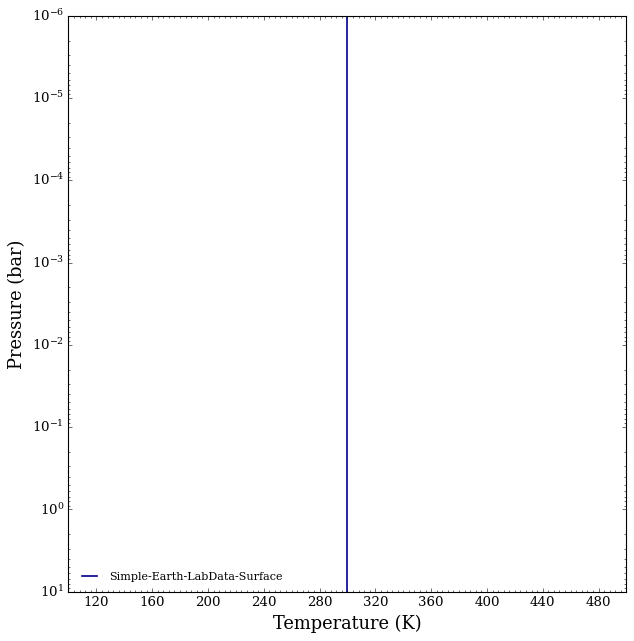

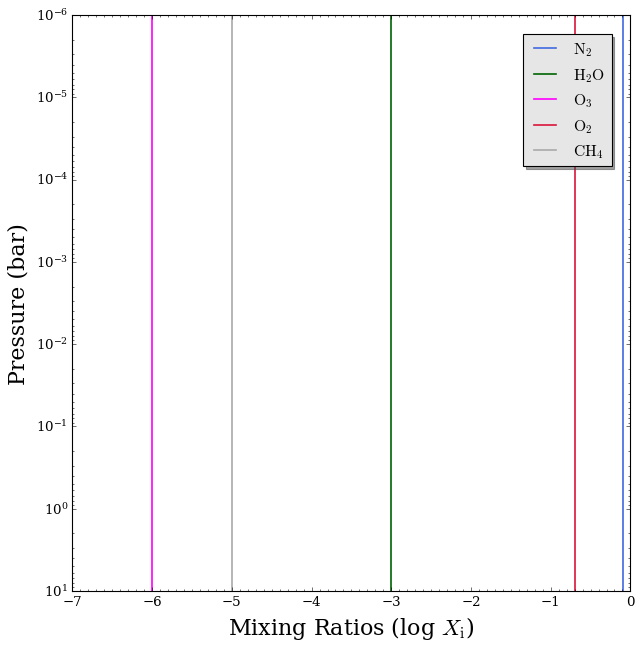

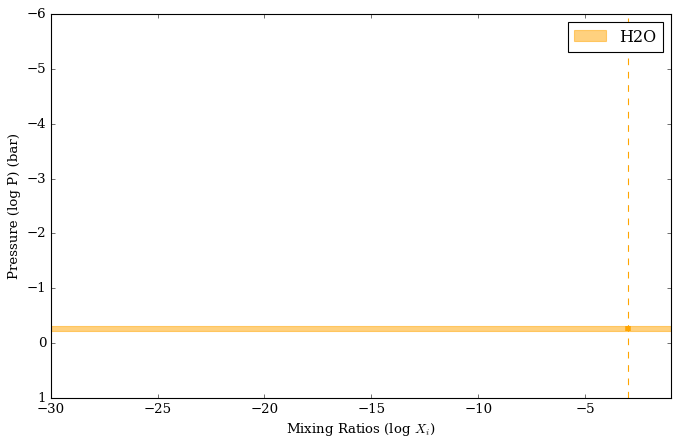

In [7]:
from POSEIDON.clouds import plot_clouds
from POSEIDON.visuals import plot_PT, plot_chem

plot_PT(planet, model_simple_lab_data, atmosphere_simple_lab_data)

plot_chem(planet, model_simple_lab_data, atmosphere_simple_lab_data)

plot_clouds(planet, model_simple_lab_data, atmosphere_simple_lab_data)

Lets also look at the surface albedos

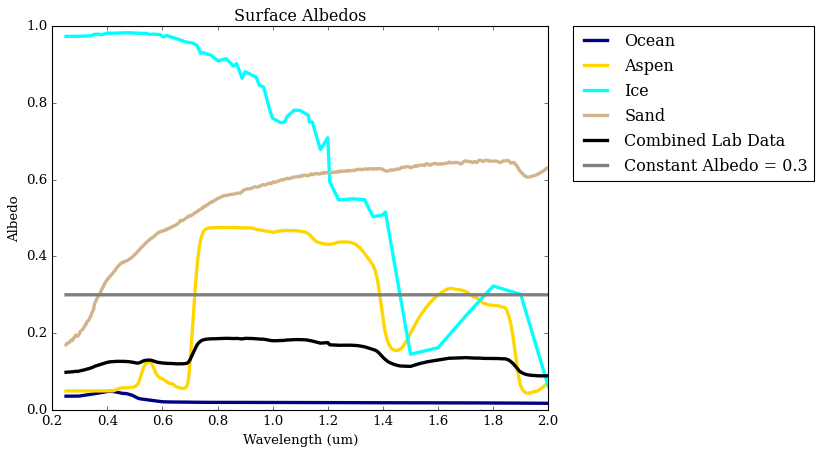

In [8]:
from POSEIDON.surfaces import load_surface_components, interpolate_surface_components

# Function that loads albedos from /inputs 
surface_component_albedos = load_surface_components(surface_components)

# 1D interpolation used in POSEIDON. Requires albedos to span entire wavelength range. 
# Here we have artificially extended aspen and antartic surfaces to 0.1 um, which is ok because they have minimal contribution at blue wavelengths anyways 
surface_component_albedos_interpolated = interpolate_surface_components(wl,surface_components,surface_component_albedos,)

# How we apply weights to albedos in POSEIDON (when surface_percentage_apply_to == 'albedos')
surface_albedo_combined = np.zeros_like(wl)

USGS_ocean_seawater_GG25_percentage = 0.70
USGS_aspen_Z26_percentage = 0.15
Grenfell1994_antarctic_Z26_percentage = 0.05
USGS_quartz_sand_GG25_percentage = 0.10

surface_component_percentages = [USGS_ocean_seawater_GG25_percentage, 
                                    USGS_aspen_Z26_percentage, 
                                    Grenfell1994_antarctic_Z26_percentage, 
                                    USGS_quartz_sand_GG25_percentage]

for n in range(len(surface_component_percentages)):
    surface_albedo_combined+= surface_component_percentages[n]*surface_component_albedos_interpolated[n]


# Ok lets plot 
import matplotlib.pyplot as plt 

plt.plot(wl, surface_component_albedos_interpolated[0], label = 'Ocean', color = 'navy', lw = 3)
plt.plot(wl, surface_component_albedos_interpolated[1], label = 'Aspen', color = 'gold', lw = 3)
plt.plot(wl, surface_component_albedos_interpolated[2], label = 'Ice', color = 'aqua', lw = 3)
plt.plot(wl, surface_component_albedos_interpolated[3], label = 'Sand', color = 'tan', lw = 3)
plt.plot(wl, surface_albedo_combined, label = 'Combined Lab Data', color = 'black', lw = 3)
plt.plot(wl, np.full_like(wl, 0.3), label = 'Constant Albedo = 0.3', color = 'gray', lw = 3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title('Surface Albedos')
plt.xlabel('Wavelength (um)')
plt.ylabel('Albedo')
plt.show()

### Compute spectra

Now, let's compute the spectra and plot it! We have two options for setting the radius ($R_p$) in the flux ratio equation
$$\frac{F_{p,\lambda}}{F_{s,\lambda}}=A_g(\lambda)\Phi(\alpha) (\frac{R_p}{a_p})^2$$
we can either use the $1~R_\oplus$ or we can use the wavelength-dependent photosphere radius (i.e., $R_{p,eff}$ where $\tau = 2/3$). 

 We can set this using the `use_photosphere_radius` flag in `compute_spectrum()`.

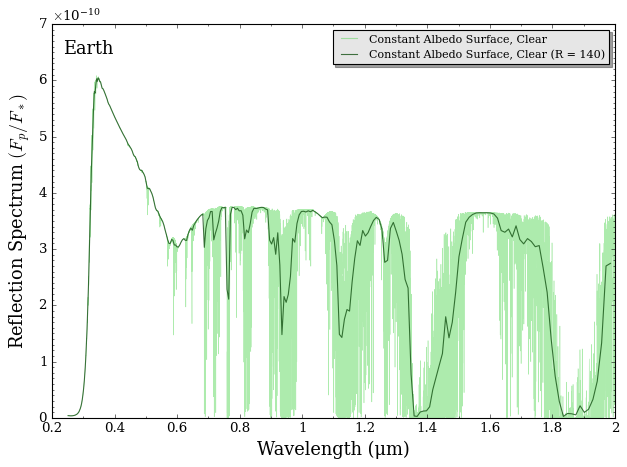

In [ ]:
from POSEIDON.core import compute_spectrum
from POSEIDON.visuals import plot_spectra
from POSEIDON.utility import plot_collection

# Compute the spectra
spectrum_FpFs_simple_const_albedo, albedo = compute_spectrum(planet, star, model_simple_const_albedo, 
                                                         atmosphere_simple_const_albedo, opac, wl, \
                                                        spectrum_type = 'emission', # <- Set to emission for reflection-only spectrum, since we measure emitted light 
                                                        return_albedo = True, use_photosphere_radius= True)

spectra = []   # Empty plot collection

# Add the model spectra to the plot collection object
spectra = plot_collection(spectrum_FpFs_simple_const_albedo, wl, collection = spectra)

# Plot the spectra
fig_spec = plot_spectra(spectra, planet, R_to_bin = 140, plot_full_res = True,
                        spectra_labels = ['Constant Albedo Surface, Clear'],
                        y_unit = 'reflection',
                        colour_list = ['limegreen'],
                        wl_axis = 'linear')

Cool! We can see the effect of N2 rayleigh scattering imprinting a reflected light scope from 0.3-0.6 microns, as well as O3 features (the large feature from 0.25-0.3 microns, and a smaller one around 0.6 microns), O2 (sharp feature at 0.75 microns), H2O [g] (large features at 0.95, 1.1, 1.4, 1.9 microns), and CH4 (1.3 microns)

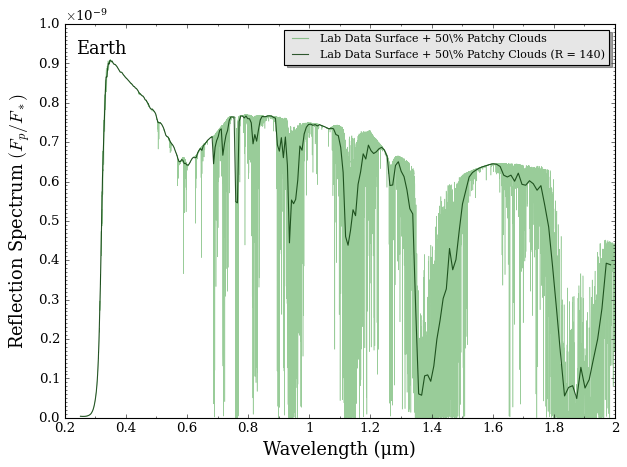

In [ ]:
from POSEIDON.core import compute_spectrum
from POSEIDON.visuals import plot_spectra
from POSEIDON.utility import plot_collection

# Compute the spectra
spectrum_FpFs_simple_lab_data, albedo = compute_spectrum(planet, star, model_simple_lab_data, 
                                                         atmosphere_simple_lab_data, opac, wl, \
                                                        spectrum_type = 'emission', # <- Set to emission for reflection-only spectrum, since we measure emitted light 
                                                        return_albedo = True, use_photosphere_radius= True)

spectra = []   # Empty plot collection

# Add the model spectra to the plot collection object
spectra = plot_collection(spectrum_FpFs_simple_lab_data, wl, collection = spectra)

# Plot the spectra
fig_spec = plot_spectra(spectra, planet, R_to_bin = 140, plot_full_res = True,
                        spectra_labels = ['Lab Data Surface + 50\% Patchy Clouds'],
                        y_unit = 'reflection',
                        colour_list = ['green'],
                        wl_axis = 'linear')

Now we can compare how using a constant albedo surface with no clouds compares to using lab data for the surface and having 50% cloud coverage:

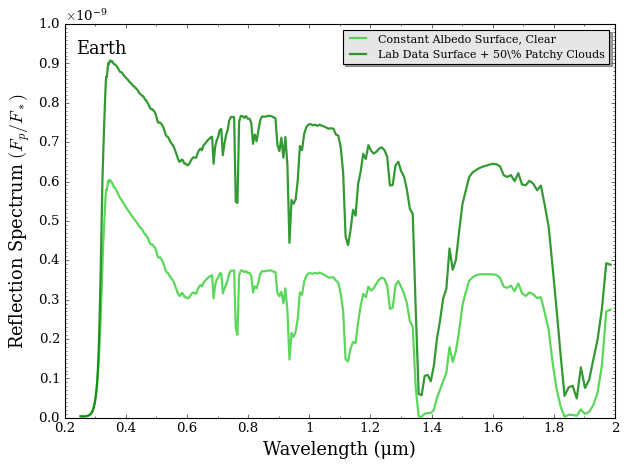

In [19]:
# Add the two model spectra to the plot collection object
spectra = []
spectra = plot_collection(spectrum_FpFs_simple_const_albedo, wl, collection = spectra)
spectra = plot_collection(spectrum_FpFs_simple_lab_data, wl, collection = spectra)

# Plot the spectra
fig_spec = plot_spectra(spectra, planet, R_to_bin = 140, plot_full_res = False,
                        y_unit = 'reflection',
                        spectra_labels = ['Constant Albedo Surface, Clear','Lab Data Surface + 50\% Patchy Clouds'],
                        colour_list = ['limegreen','green'],
                        wl_axis = 'linear')

As you can clear see above, opaque water clouds boost the overall reflection of the atmosphere while the surface albedo shapes the spectrum in unique ways. 

#### Generating synthetic HWO data 

Cool, now we have a spectrum! Now let's add some *very* simple constant noise to the data at the expected nominal wavelength resolution of the Habitable Worlds Observatory (computed in Zelakiewicz et al 2026). We will just apply simple Gaussian noise to a $\mathcal{R}=140$ spectra. We can then plot it with the forward model to see what it looks like.

Here, we will just use the spectrum using lab data from above.

In [20]:
from POSEIDON.instrument import generate_syn_data_from_user
from POSEIDON.core import load_data

data_dir = './POSEIDON_output/' + planet_name
instrument = 'HWO'

generate_syn_data_from_user(planet, wl, spectrum_FpFs_simple_lab_data, data_dir, 
                            instrument, R_data = 140, err_data = 4e-5,
                            wl_start = 0.41, wl_end = 1.7,
                            label = 'Simple w/ Lab Data Surface', 
                            Gauss_scatter = True)


datasets = ['Earth_SYNTHETIC_HWO_Simple.dat']

# Load dataset, pre-load instrument PSF and transmission function
data = load_data(data_dir, datasets, [instrument], wl)


fig_spec = plot_spectra(spectra, planet, R_to_bin = 140, plot_full_res = False,
                        spectra_labels = ['True Model'],
                        colour_list = ['forestgreen'], 
                        plt_label = ('Sim. Data vs. Forward Model'),
                        y_unit = 'Fp/Fs',
                        y_min = -1e-10, y_max = 1.2e-9,
                        wl_min = 0.4, wl_max = 1.8,
                        show_data = True,
                        data_properties = data,
                        data_tylabels = ['Simulated HWO Data'],
                        data_colour_list = ['cyan'],
                        data_marker_list = ['o'],
                        data_marker_size_list = [3],
                        )

Creating synthetic data
POSEIDON does not currently have an instrument transmission function for HWO, so a box function will be used.


FileNotFoundError: [Errno 2] No such file or directory: './POSEIDON_output/Earth/Earth_SYNTHETIC_HWO_Simple w/ Lab Data Surface.dat'